# 1.3 — Clustering nonMalignant + Análisis de variables clínicas

**Objetivos**:

1. Generar etiquetas de cluster para muestras **nonMalignant** (`nm_cluster`) de forma independiente en train y test.
2. Persistir los parquets con la nueva columna `nm_cluster`.
3. Análisis de asociación estadística entre variables clínicas (Age, Sex) y tipos de cáncer.
4. Análisis de distribución de clusters (mal_cluster, nm_cluster) por tipo de cáncer.

Pipeline de clustering: `log1p → StandardScaler → PCA(90%) → KMeans(k=2)`

**Prevención de data leakage**: Todos los pipelines se ajustan de forma independiente por conjunto.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

from genomics_dl.models.heterogeneity import (
    generate_nonmalignant_clusters,
    align_cluster_labels,
    compute_umap_from_pca,
    plot_umap,
    compute_clinical_associations,
    plot_clinical_associations,
)

In [3]:
DATA_PROCESSED = Path("../data/processed")
FIGURES_DIR = Path("../reports/figures/clinical")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Partimos de los parquets clustered (ya tienen mal_cluster)
TRAIN_PATH = DATA_PROCESSED / "gse183635_tep_tpm_train_clustered.parquet"
TEST_PATH  = DATA_PROCESSED / "gse183635_tep_tpm_test_clustered.parquet"

RANDOM_STATE = 42
PCA_VARIANCE = 0.90
NM_N_CLUSTERS = 2

metadata_cols = [
    "Sample ID", "Patient_group", "Stage", "Sex", "Age",
    "Sample-supplying institution", "Training series",
    "Evaluation series", "Validation series", "lib.size",
    "classificationScoreCancer", "Class_group", "mal_cluster",
]

## 1. Carga de datos

In [4]:
df_train = pd.read_parquet(TRAIN_PATH)
df_test  = pd.read_parquet(TEST_PATH)

if "Sample ID" in df_train.columns:
    df_train = df_train.set_index("Sample ID", drop=False)
if "Sample ID" in df_test.columns:
    df_test = df_test.set_index("Sample ID", drop=False)

gene_cols = [c for c in df_train.columns if c not in metadata_cols]

print(f"Train: {len(df_train)} muestras, Test: {len(df_test)} muestras")
print(f"Genes: {len(gene_cols)}")
print(f"mal_cluster ya presente: {'mal_cluster' in df_train.columns}")

Train: 1880 muestras, Test: 471 muestras
Genes: 5440
mal_cluster ya presente: True


---
## 2. Clustering nonMalignant

Pipeline independiente por conjunto: `log1p → StandardScaler → PCA(90%) → KMeans(k=2)`

### 2.1 Filtrar muestras nonMalignant

In [5]:
mask_nm_train = df_train["Class_group"] == "nonMalignant"
mask_nm_test  = df_test["Class_group"] == "nonMalignant"

X_nm_train = df_train.loc[mask_nm_train, gene_cols]
X_nm_test  = df_test.loc[mask_nm_test, gene_cols]

meta_nm_train = df_train.loc[mask_nm_train, metadata_cols].copy()
meta_nm_test  = df_test.loc[mask_nm_test, metadata_cols].copy()

print(f"nonMalignant train: {X_nm_train.shape}")
print(f"nonMalignant test:  {X_nm_test.shape}")
print(f"\nPatient_group en nonMalignant (train):")
print(meta_nm_train["Patient_group"].value_counts())

nonMalignant train: (578, 5440)
nonMalignant test:  (145, 5440)

Patient_group en nonMalignant (train):
Patient_group
Asymptomatic controls             310
Multiple sclerosis                 68
Pulmonary Hypertension             59
Pancreatic diseases                44
Medically-intractable epilepsy     36
Angina pectoris                    22
Former sarcoma                     17
nSTEMI                             12
Bowel disease                       5
Hematuria                           5
Name: count, dtype: int64


### 2.2 Clustering en TRAIN

In [6]:
labels_nm_train, scaler_nm_train, pca_nm_train = generate_nonmalignant_clusters(
    X_nm_train,
    pca_variance=PCA_VARIANCE,
    n_clusters=NM_N_CLUSTERS,
    random_state=RANDOM_STATE,
)

print(f"Train — PCA componentes: {pca_nm_train.n_components_}")
print(f"Train — distribución: {dict(zip(*np.unique(labels_nm_train, return_counts=True)))}")

Train — PCA componentes: 268
Train — distribución: {np.int32(0): np.int64(385), np.int32(1): np.int64(193)}


### 2.3 Clustering en TEST (mismo k, pipeline independiente)

In [7]:
labels_nm_test, scaler_nm_test, pca_nm_test = generate_nonmalignant_clusters(
    X_nm_test,
    pca_variance=PCA_VARIANCE,
    n_clusters=NM_N_CLUSTERS,
    random_state=RANDOM_STATE,
)

print(f"Test — PCA componentes: {pca_nm_test.n_components_}")
print(f"Test — distribución: {dict(zip(*np.unique(labels_nm_test, return_counts=True)))}")

Test — PCA componentes: 73
Test — distribución: {np.int32(0): np.int64(82), np.int32(1): np.int64(63)}


### 2.4 Alineación de etiquetas

Usamos la proporción de "Asymptomatic controls" como heurística para alinear cluster 0 en ambos conjuntos.

In [8]:
labels_nm_train_al, labels_nm_test_al = align_cluster_labels(
    labels_nm_train, labels_nm_test,
    meta_nm_train, meta_nm_test,
    reference_group="Asymptomatic controls",
    patient_group_col="Patient_group",
)

print("Train alineado:", dict(zip(*np.unique(labels_nm_train_al, return_counts=True))))
print("Test alineado: ", dict(zip(*np.unique(labels_nm_test_al, return_counts=True))))

Train alineado: {np.int32(0): np.int64(385), np.int32(1): np.int64(193)}
Test alineado:  {np.int32(0): np.int64(82), np.int32(1): np.int64(63)}


### 2.5 Validación: crosstab Patient_group × nm_cluster

In [9]:
meta_nm_train["nm_cluster"] = labels_nm_train_al
meta_nm_test["nm_cluster"]  = labels_nm_test_al

print("=== TRAIN ===")
ct_train = pd.crosstab(meta_nm_train["nm_cluster"], meta_nm_train["Patient_group"])
display(ct_train)

chi2_tr, p_tr, _, _ = chi2_contingency(ct_train)
print(f"Chi2 Patient_group vs nm_cluster (train): {chi2_tr:.2f}, p={p_tr:.2e}")

print("\n=== TEST ===")
ct_test = pd.crosstab(meta_nm_test["nm_cluster"], meta_nm_test["Patient_group"])
display(ct_test)

chi2_te, p_te, _, _ = chi2_contingency(ct_test)
print(f"Chi2 Patient_group vs nm_cluster (test): {chi2_te:.2f}, p={p_te:.2e}")

=== TRAIN ===


Patient_group,Angina pectoris,Asymptomatic controls,Bowel disease,Former sarcoma,Hematuria,Medically-intractable epilepsy,Multiple sclerosis,Pancreatic diseases,Pulmonary Hypertension,nSTEMI
nm_cluster,,,,,,,,,,
0,6,221,3,3,4,22,54,35,34,3
1,16,89,2,14,1,14,14,9,25,9


Chi2 Patient_group vs nm_cluster (train): 57.48, p=4.09e-09

=== TEST ===


Patient_group,Angina pectoris,Asymptomatic controls,Bowel disease,Former sarcoma,Medically-intractable epilepsy,Multiple sclerosis,Pancreatic diseases,Pulmonary Hypertension,nSTEMI
nm_cluster,,,,,,,,,
0,0,52,2,3,6,10,3,5,1
1,4,28,2,6,2,8,3,8,2


Chi2 Patient_group vs nm_cluster (test): 13.18, p=1.06e-01


### 2.6 UMAP — Visualización de clusters nonMalignant

/workspaces/TFM/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


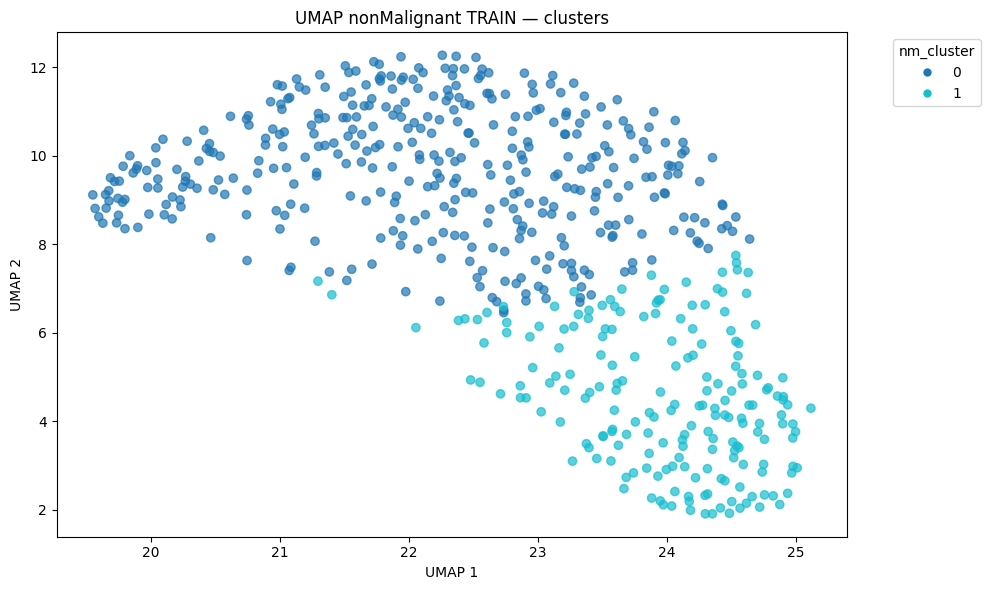

In [10]:
# UMAP para train
X_log_nm_train = np.log1p(X_nm_train.values)
X_scaled_nm_train = scaler_nm_train.transform(X_log_nm_train)
X_pca_nm_train = pca_nm_train.transform(X_scaled_nm_train)

X_umap_nm_train, _ = compute_umap_from_pca(X_pca_nm_train, random_state=RANDOM_STATE)

plot_umap(
    X_umap=X_umap_nm_train,
    color=pd.Series(labels_nm_train_al, index=meta_nm_train.index, name="nm_cluster"),
    title="UMAP nonMalignant TRAIN — clusters",
    figsize=(10, 6),
)

/workspaces/TFM/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


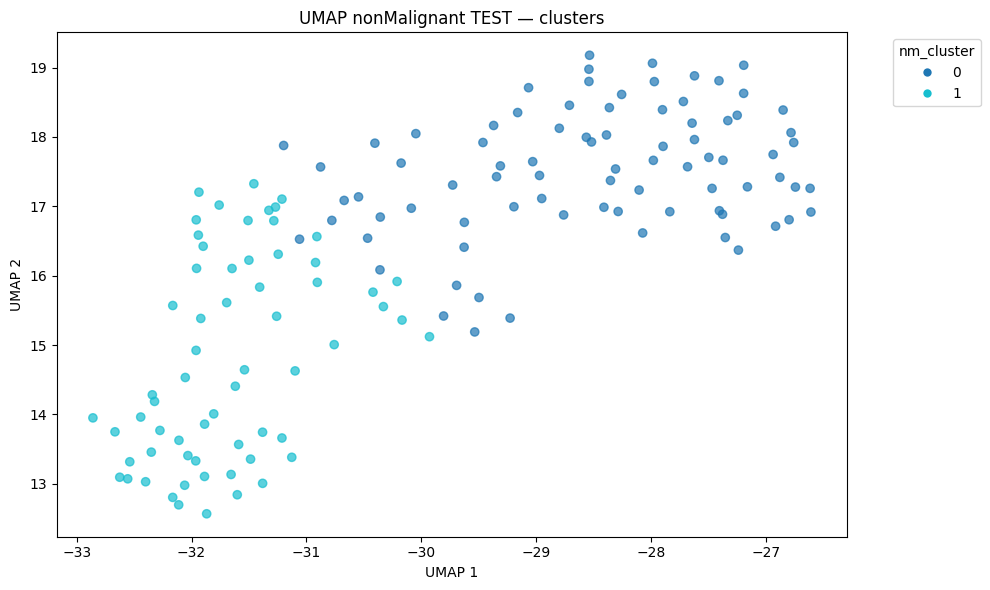

In [11]:
# UMAP para test
X_log_nm_test = np.log1p(X_nm_test.values)
X_scaled_nm_test = scaler_nm_test.transform(X_log_nm_test)
X_pca_nm_test = pca_nm_test.transform(X_scaled_nm_test)

X_umap_nm_test, _ = compute_umap_from_pca(X_pca_nm_test, random_state=RANDOM_STATE)

plot_umap(
    X_umap=X_umap_nm_test,
    color=pd.Series(labels_nm_test_al, index=meta_nm_test.index, name="nm_cluster"),
    title="UMAP nonMalignant TEST — clusters",
    figsize=(10, 6),
)

### 2.7 Guardar datos con nm_cluster

In [12]:
# Añadir columna nm_cluster (NaN para Malignant)
df_train["nm_cluster"] = np.nan
df_train.loc[mask_nm_train, "nm_cluster"] = labels_nm_train_al.astype(float)

df_test["nm_cluster"] = np.nan
df_test.loc[mask_nm_test, "nm_cluster"] = labels_nm_test_al.astype(float)

print("Train nm_cluster:")
print(df_train["nm_cluster"].value_counts(dropna=False))
print("\nTest nm_cluster:")
print(df_test["nm_cluster"].value_counts(dropna=False))

Train nm_cluster:
nm_cluster
NaN    1302
0.0     385
1.0     193
Name: count, dtype: int64

Test nm_cluster:
nm_cluster
NaN    326
0.0     82
1.0     63
Name: count, dtype: int64


In [13]:
# Sobrescribir parquets (ya contenían mal_cluster, ahora añadimos nm_cluster)
OUT_TRAIN = DATA_PROCESSED / "gse183635_tep_tpm_train_clustered.parquet"
OUT_TEST  = DATA_PROCESSED / "gse183635_tep_tpm_test_clustered.parquet"

df_train.to_parquet(OUT_TRAIN, index=False)
df_test.to_parquet(OUT_TEST, index=False)

print(f"Guardado: {OUT_TRAIN}")
print(f"Guardado: {OUT_TEST}")
print(f"\nColumnas totales: {len(df_train.columns)}")
print(f"Columnas nuevas: mal_cluster, nm_cluster")

Guardado: ../data/processed/gse183635_tep_tpm_train_clustered.parquet
Guardado: ../data/processed/gse183635_tep_tpm_test_clustered.parquet

Columnas totales: 5454
Columnas nuevas: mal_cluster, nm_cluster


---
## 3. Análisis de variables clínicas

### 3.1 Missing values

In [14]:
clinical_vars = ["Age", "Sex", "mal_cluster", "nm_cluster"]

print("=== MISSING VALUES ===")
for var in clinical_vars:
    if var in df_train.columns:
        na_train = df_train[var].isna().sum()
        na_test = df_test[var].isna().sum()
        print(f"{var:15s}  train NaN: {na_train:4d}/{len(df_train)}  "
              f"test NaN: {na_test:3d}/{len(df_test)}")

# Sex: valores especiales
print("\n=== Sex value counts (train) ===")
print(df_train["Sex"].value_counts(dropna=False))
print("\n=== Sex value counts (test) ===")
print(df_test["Sex"].value_counts(dropna=False))

=== MISSING VALUES ===
Age              train NaN:   18/1880  test NaN:   5/471
Sex              train NaN:    0/1880  test NaN:   0/471
mal_cluster      train NaN:  578/1880  test NaN: 145/471
nm_cluster       train NaN: 1302/1880  test NaN: 326/471

=== Sex value counts (train) ===
Sex
F       978
M       888
n.a.     14
Name: count, dtype: int64

=== Sex value counts (test) ===
Sex
F       242
M       223
n.a.      6
Name: count, dtype: int64


### 3.2 Asociación estadística: Sex × tipo de cáncer

In [15]:
# Construir y multiclass original (19 clases) para el análisis
from genomics_dl.models.train_multiclass import build_y_multiclass

y_train = build_y_multiclass(
    df_train, class_group_col="Class_group",
    patient_group_col="Patient_group",
)
df_train["target_19"] = y_train

y_test = build_y_multiclass(
    df_test, class_group_col="Class_group",
    patient_group_col="Patient_group",
)
df_test["target_19"] = y_test

print(f"Clases únicas: {len(np.unique(y_train))}")
print(pd.Series(y_train).value_counts())

Clases únicas: 19
nonMalignant                  578
Non-small-cell lung cancer    417
Ovarian cancer                114
Glioma                        113
Pancreatic cancer              93
Breast cancer                  80
Head and neck cancer           79
Cholangiocarcinoma             71
Colorectal cancer              69
Melanoma                       54
Sarcoma                        44
Endometrial cancer             34
Prostate cancer                23
Multiple Myeloma               22
Urothelial cancer              22
Renal cell cancer              20
Hepatocellular carcinoma       19
Lymphoma                       16
Esophageal carcinoma           12
Name: count, dtype: int64


In [16]:
# Asociación estadística (train)
results_train = compute_clinical_associations(
    df_train, target_col="target_19",
    age_col="Age", sex_col="Sex",
)

print("=== Sex × tipo de cáncer (train) ===")
sex_res = results_train["sex"]
print(f"Test: {sex_res['test']}")
print(f"Chi2: {sex_res['chi2']:.2f}")
print(f"p-value: {sex_res['p_value']:.2e}")
print(f"V de Cramer: {sex_res['cramers_v']:.4f}")
print(f"DOF: {sex_res['dof']}")

print("\nTabla de contingencia:")
display(sex_res["contingency_table"])

=== Sex × tipo de cáncer (train) ===
Test: chi2_contingency
Chi2: 318.66
p-value: 6.89e-57
V de Cramer: 0.4132
DOF: 18

Tabla de contingencia:


Sex,F,M
target_19,,
Breast cancer,80,0
Cholangiocarcinoma,37,34
Colorectal cancer,30,39
Endometrial cancer,34,0
Esophageal carcinoma,3,9
Glioma,31,82
Head and neck cancer,20,59
Hepatocellular carcinoma,5,14
Lymphoma,7,9


### 3.3 Asociación estadística: Age × tipo de cáncer

In [17]:
age_res = results_train["age"]
print("=== Age × tipo de cáncer (train) ===")
print(f"Test: {age_res['test']}")
print(f"Estadístico H: {age_res['statistic']:.2f}")
print(f"p-value: {age_res['p_value']:.2e}")

print("\nEstadísticas descriptivas por grupo:")
display(age_res["descriptive_by_group"].round(1))

=== Age × tipo de cáncer (train) ===
Test: kruskal_wallis
Estadístico H: 328.68
p-value: 5.89e-59

Estadísticas descriptivas por grupo:


,count,mean,median,std,min,max
target_19,,,,,,
Breast cancer,80,57.2,58.0,10.8,35.0,81.0
Cholangiocarcinoma,71,66.8,68.0,10.1,45.0,92.0
Colorectal cancer,69,64.6,66.0,11.3,31.0,85.0
Endometrial cancer,34,65.9,64.5,8.3,53.0,86.0
Esophageal carcinoma,12,65.3,66.5,10.5,46.0,80.0
Glioma,109,52.0,53.0,14.4,20.0,79.0
Head and neck cancer,79,62.8,63.0,9.6,37.0,84.0
Hepatocellular carcinoma,19,65.8,64.0,10.2,52.0,84.0
Lymphoma,16,44.5,49.0,16.8,19.0,66.0


### 3.4 Visualizaciones

/workspaces/TFM/genomics_dl/models/heterogeneity.py:1023: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


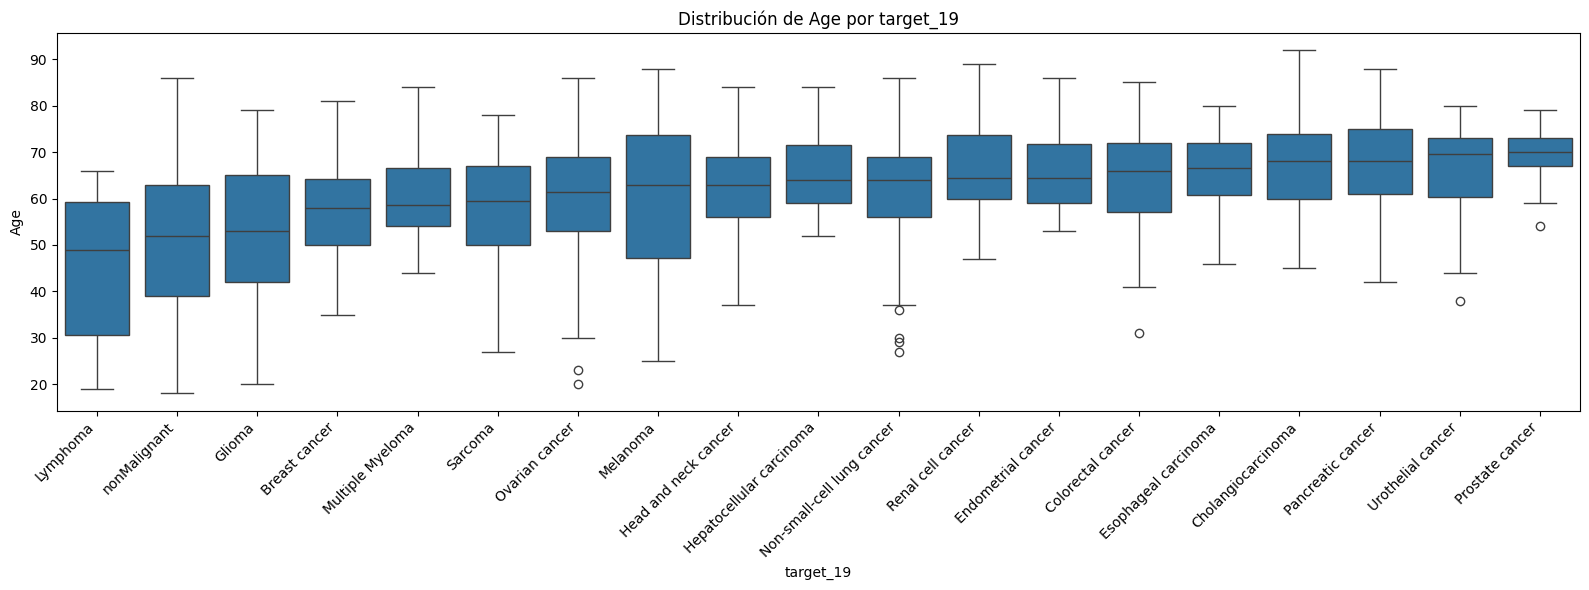

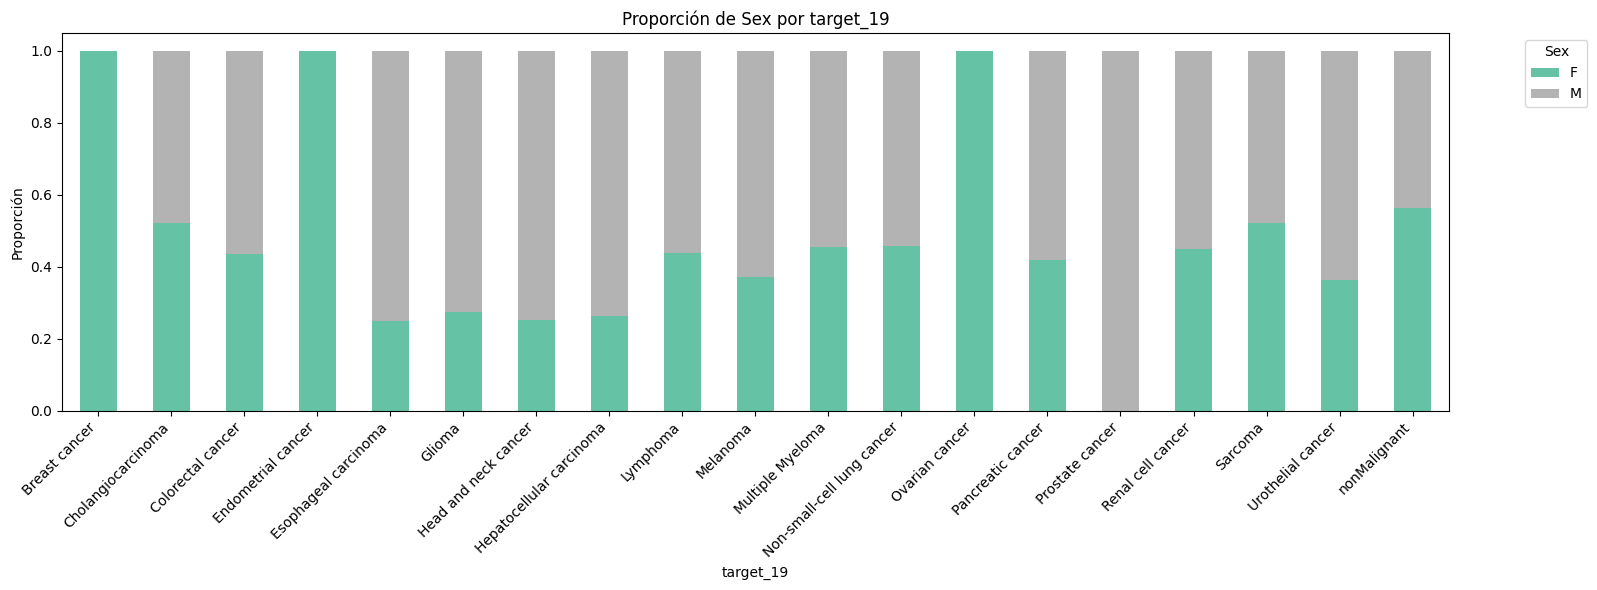

In [18]:
plot_clinical_associations(
    df_train, target_col="target_19",
    age_col="Age", sex_col="Sex",
    output_dir=FIGURES_DIR,
    figsize_age=(16, 6),
    figsize_sex=(16, 6),
)

### 3.5 Distribución de clusters por tipo de cáncer

In [19]:
# Distribución de mal_cluster por Patient_group (solo Malignant)
df_mal_train = df_train[df_train["Class_group"] == "Malignant"].copy()

print("=== mal_cluster × Patient_group (train) ===")
ct_mal = pd.crosstab(
    df_mal_train["Patient_group"],
    df_mal_train["mal_cluster"],
    margins=True,
)
display(ct_mal)

# Proporciones normalizadas
print("\nProporciones (por fila):")
ct_mal_norm = pd.crosstab(
    df_mal_train["Patient_group"],
    df_mal_train["mal_cluster"],
    normalize="index",
)
display(ct_mal_norm.round(3))

=== mal_cluster × Patient_group (train) ===


mal_cluster,0.0,1.0,All
Patient_group,,,
Breast cancer,76,4,80
Cholangiocarcinoma,62,9,71
Colorectal cancer,62,7,69
Endometrial cancer,17,17,34
Esophageal carcinoma,4,8,12
Glioma,79,34,113
Head and neck cancer,24,55,79
Hepatocellular carcinoma,19,0,19
Lymphoma,14,2,16



Proporciones (por fila):


mal_cluster,0.0,1.0
Patient_group,,
Breast cancer,0.950,0.050
Cholangiocarcinoma,0.873,0.127
Colorectal cancer,0.899,0.101
Endometrial cancer,0.500,0.500
Esophageal carcinoma,0.333,0.667
Glioma,0.699,0.301
Head and neck cancer,0.304,0.696
Hepatocellular carcinoma,1.000,0.000
Lymphoma,0.875,0.125


In [20]:
# Distribución de nm_cluster por Patient_group (solo nonMalignant)
df_nm_train = df_train[df_train["Class_group"] == "nonMalignant"].copy()

print("=== nm_cluster × Patient_group (train) ===")
ct_nm = pd.crosstab(
    df_nm_train["Patient_group"],
    df_nm_train["nm_cluster"],
    margins=True,
)
display(ct_nm)

# Proporciones normalizadas
print("\nProporciones (por fila):")
ct_nm_norm = pd.crosstab(
    df_nm_train["Patient_group"],
    df_nm_train["nm_cluster"],
    normalize="index",
)
display(ct_nm_norm.round(3))

=== nm_cluster × Patient_group (train) ===


nm_cluster,0.0,1.0,All
Patient_group,,,
Angina pectoris,6,16,22
Asymptomatic controls,221,89,310
Bowel disease,3,2,5
Former sarcoma,3,14,17
Hematuria,4,1,5
Medically-intractable epilepsy,22,14,36
Multiple sclerosis,54,14,68
Pancreatic diseases,35,9,44
Pulmonary Hypertension,34,25,59



Proporciones (por fila):


nm_cluster,0.0,1.0
Patient_group,,
Angina pectoris,0.273,0.727
Asymptomatic controls,0.713,0.287
Bowel disease,0.600,0.400
Former sarcoma,0.176,0.824
Hematuria,0.800,0.200
Medically-intractable epilepsy,0.611,0.389
Multiple sclerosis,0.794,0.206
Pancreatic diseases,0.795,0.205
Pulmonary Hypertension,0.576,0.424


### 3.6 Barplot de clusters por tipo de cáncer

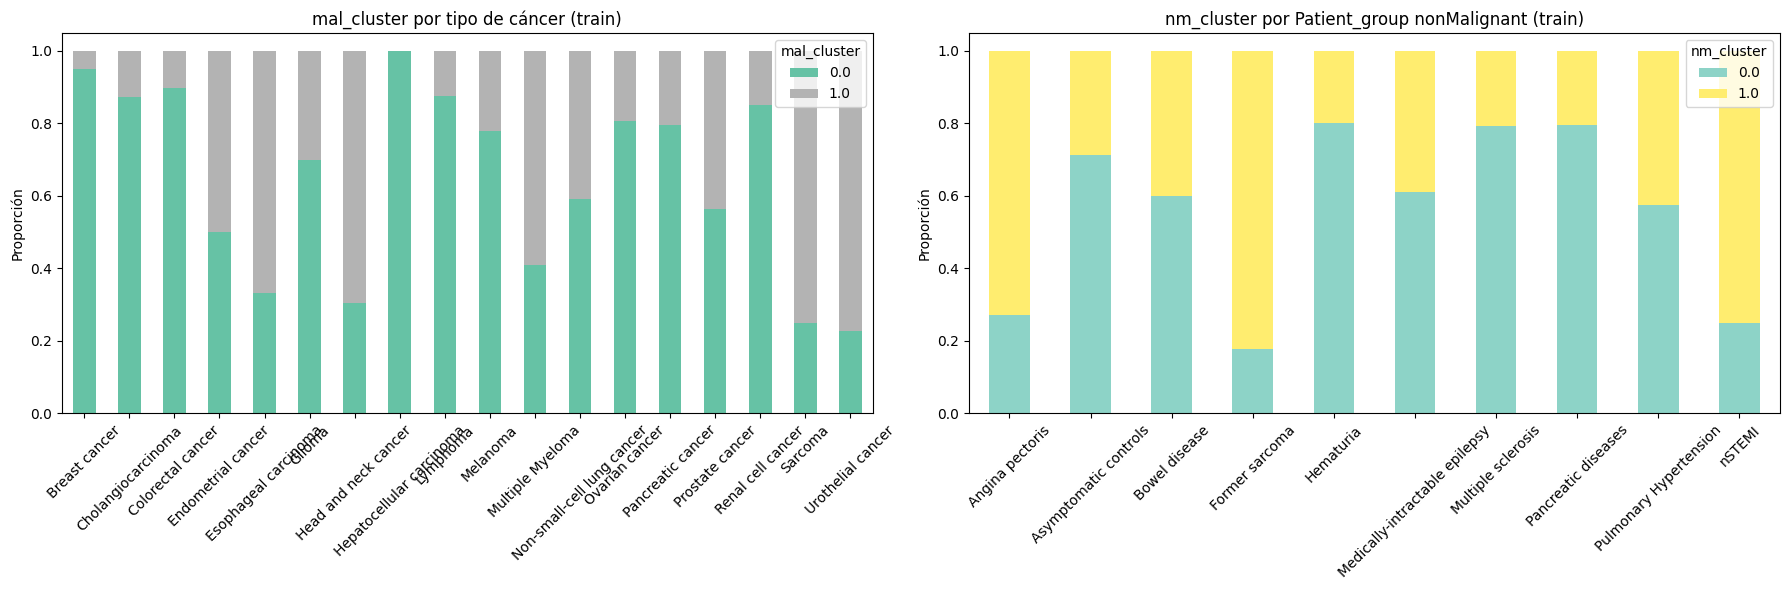

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# mal_cluster
ct_mal_norm.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("mal_cluster por tipo de cáncer (train)")
axes[0].set_ylabel("Proporción")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="mal_cluster")

# nm_cluster
ct_nm_norm.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set3")
axes[1].set_title("nm_cluster por Patient_group nonMalignant (train)")
axes[1].set_ylabel("Proporción")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="nm_cluster")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "clusters_by_cancer_type.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

---
## 4. Resumen

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `mal_cluster` | Cluster dummy | 0/1 para Malignant, NaN para nonMalignant |
| `nm_cluster` | Cluster dummy | 0/1 para nonMalignant, NaN para Malignant |
| `Age` | Continua | Edad del paciente (NaN imputados en pipeline) |
| `Sex` | Categórica | F/M/n.a. (imputados en pipeline) |

Estas 4 variables se incorporarán como **features en X** (no en y) en los notebooks 4.2 y 5.2.

In [22]:
# Verificación final: columnas en los parquets guardados
df_check = pd.read_parquet(OUT_TRAIN)
print(f"Columnas totales: {len(df_check.columns)}")
print(f"mal_cluster presente: {'mal_cluster' in df_check.columns}")
print(f"nm_cluster presente:  {'nm_cluster' in df_check.columns}")
print(f"\nmal_cluster distribución:")
print(df_check["mal_cluster"].value_counts(dropna=False))
print(f"\nnm_cluster distribución:")
print(df_check["nm_cluster"].value_counts(dropna=False))

# Limpiar columna temporal
df_train.drop(columns=["target_19"], inplace=True, errors="ignore")
df_test.drop(columns=["target_19"], inplace=True, errors="ignore")

Columnas totales: 5454
mal_cluster presente: True
nm_cluster presente:  True

mal_cluster distribución:
mal_cluster
0.0    867
NaN    578
1.0    435
Name: count, dtype: int64

nm_cluster distribución:
nm_cluster
NaN    1302
0.0     385
1.0     193
Name: count, dtype: int64
